# 14-Feb-26 Assignment -- weighted mean

## The Model
The model describes the probabilities for an experiment: a set a $N$, say 100, measurements of a single value $\mu$, each with an uncertainty $\sigma_i$. The uncertainties are not all the same, choose some fixed scheme, say, alternating between two values, or randomly selected with the model is initialized.

## An experimental result
This will be the weighted mean of the measurements. You need to derive the corresponding forumula, and its expected variance.

## Repeated experiments
Run a large number of experiments, recording the results, from which you get the experimental variance. Compare this with the expected variance. 


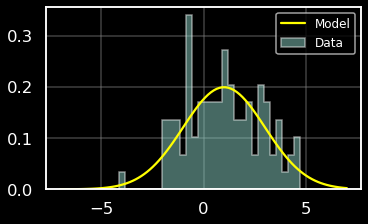

In [66]:
%run pylib/tools dark
from scipy.stats import norm
from utilities.ipynb_docgen import show

class Model:
    def __init__(self, mu=0, sigma=1):
        self.normal = norm(loc=mu, scale=sigma)
        self.mu = mu
        self.sigma = sigma
    
    def pdf(self, x):
        return self.normal.pdf(x)

    def experiment(self, size=1000):
        self.size = size
        return self.normal.rvs(size=size)

    def result(self, data):
        return data.mean()

m = Model(mu=1, sigma=2)
x = np.linspace(-7, 7, 100)
plt.plot(x, m.pdf(x), c='yellow', label='Model') 
data = m.experiment(size=100)
plt.hist(data, bins=30, density=True, histtype='stepfilled', alpha=0.5, label='Data')
plt.legend(loc='upper right', fontsize=12)
plt.show()  

In [63]:
trials = 10000
results = np.array([m.result(m.experiment(size=100)) for _ in range(trials)])
print(f"""mean {results.mean():.3f}, measured sigma {results.std():.3f}, expected sigma {m.sigma/np.sqrt(m.size-1):.3f}""")

mean 0.999, measured sigma 0.201, expected sigma 0.201


In [70]:
show(f""" ## combine two models with different variances""")
m1 = Model(mu=1, sigma=2)
m2 = Model(mu=1, sigma=1)
r1 = np.array([m1.result(m1.experiment(size=100)) for _ in range(trials)])
r2 = np.array([m2.result(m2.experiment(size=100)) for _ in range(trials)])
print(f"""Model 1: mean {r1.mean():.3f}, measured sigma {r1.std():.3f}, expected sigma {m1.sigma/np.sqrt(m1.size-1):.3f}""")
print(f"""Model 2: mean {r2.mean():.3f}, measured sigma {r2.std():.3f}, expected sigma {m2.sigma/np.sqrt(m2.size-1):.3f}""")


## combine two models with different variances

Model 1: mean 1.002, measured sigma 0.199, expected sigma 0.201
Model 2: mean 0.999, measured sigma 0.100, expected sigma 0.101


In [98]:
show(f"""###  Experiment """)
class TwoModels:
    def __init__(self, m1, m2):
        self.m1 = m1
        self.m2 = m2
    
    def experiment(self, size=100):
        self.size = size
        vals =  np.concatenate([self.m1.experiment(size=size//2), self.m2.experiment(size=size//2)])
        sigs = np.concatenate([np.full(size//2, self.m1.sigma), np.full(size//2, self.m2.sigma)])
        return np.array([vals, sigs])
    
    def result(self, data):
        x, s = data
        w = 1/s**2
        return (x*w).sum()/w.sum(), np.sqrt(1/w.sum())
        

tm = TwoModels(m1, m2)
results = np.array([tm.result(tm.experiment(size=100))[0] for _ in range(trials)])
print(f"""Combined Model with {trials} trials: mean {results.mean():.3f}, measured sigma {results.std():.3f}""")

###  Experiment 

Combined Model with 10000 trials: mean 1.001, measured sigma 0.127


In [94]:
tm.result(tm.experiment(size=100))

(0.9337320465751219, 0.12649110640673517)